<a href="https://colab.research.google.com/github/shankar045/1BM23CS309-ML-LAB/blob/main/1BM23CS309_Lab_8_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy: 0.93025

Confusion Matrix:
 [[149   0   1   0   0   0   0   0   0   0   0   0   1   0   0   0   0   0
    0   0   3   0   0   0   4   0]
 [  0 146   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   3
    4   0   0   0   0   0   0   0]
 [  0   0 140   0   1   0   2   0   0   0   0   0   0   0   2   0   0   0
    0   0   2   0   0   0   0   0]
 [  0   8   0 150   0   0   0   0   0   0   0   0   0   1   0   0   0   2
    0   0   0   0   0   0   0   0]
 [  0   1   1   0 144   0   5   0   0   0   0   0   0   0   0   0   0   1
    0   0   0   0   0   0   0   2]
 [  0   0   0   1   2 141   0   2   1   0   0   0   0   3   0   1   0   0
    2   2   0   0   0   0   0   0]
 [  0   1   0   1   2   0 147   0   0   0   0   0   0   0   1   0   2   1
    0   0   0   0   0   0   0   0]
 [  0   5   0   6   0   0   1 119   0   0   0   0   0   1   4   0   1   8
    0   0   1   0   0   1   0   0]
 [  0   0   0   0   0   5   0   0 134   7   0   0   0   0   0   0   0   0
    2   0   0   

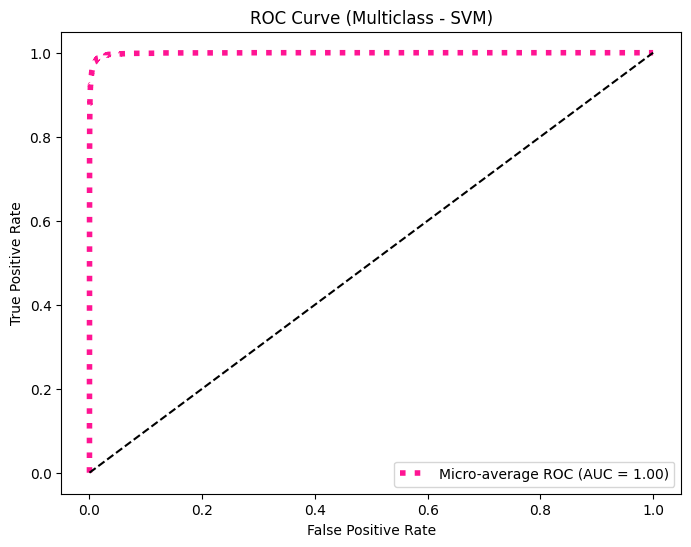


AUC Score (Micro-average): 0.9989422425


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

df = pd.read_csv("letter-recognition.csv")

df.columns = ["letter","xbox","ybox","width","height","onpix","xbar","ybar",
              "x2bar","y2bar","xybar","x2ybar","xy2bar","xedge","xedgey","yedge","yedgex"]

X = df.drop("letter", axis=1)
y = df["letter"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Binarize labels (one-vs-rest)
classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)

y_score = svm_model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(8,6))
plt.plot(fpr["micro"], tpr["micro"],
         label=f"Micro-average ROC (AUC = {roc_auc['micro']:.2f})",
         color='deeppink', linestyle=':', linewidth=4)

plt.plot([0,1], [0,1], 'k--')  # diagonal line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multiclass - SVM)")
plt.legend(loc="lower right")
plt.show()

# Print AUC
print("\nAUC Score (Micro-average):", roc_auc["micro"])